<a href="https://colab.research.google.com/github/idkisma3l/Examen-Bismestral-ISI/blob/main/Examen01_B_KPIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ISID223 — Introducción a los Sistemas de Información 2026-A
**Estudiante: Ismael Salazar**

---
## Examen Bimestral — IBM HR Analytics: Employee Attrition & Performance

> **Dataset:** `WA_Fn-UseC_-HR-Employee-Attrition.csv`  
> **Registros:** 1 470 empleados · 35 variables  
> **Objetivo:** Calcular 4 KPIs estratégicos del módulo de Gestión de Talento Humano (HRIS/ERP)


---
##  Paso 1 — Importar librerías y cargar el dataset

In [ ]:
from google.colab import widgets
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# Cargar dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f" Dataset cargado correctamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"   Variables clave: Attrition, Department, JobRole, MonthlyIncome, WorkLifeBalance")
df.head(3)

 Dataset cargado correctamente
   Filas    : 1,470
   Columnas : 35
   Variables clave: Attrition, Department, JobRole, MonthlyIncome, WorkLifeBalance


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


---
## KPI 1 — Tasa de Rotación de Personal (Attrition Rate)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KPI 1 · TASA DE ROTACIÓN DE PERSONAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Periodo analizado : Histórico completo del dataset
  Total de empleados: 1,470
  Empleados activos : 1,233
  Empleados salidos : 237
  ─────────────────────────────────────
   Attrition Rate = 16.12%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


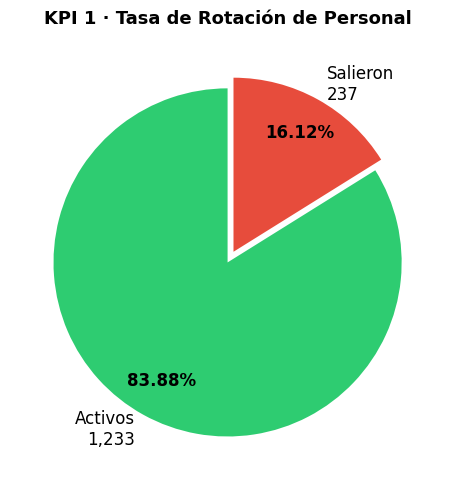

In [ ]:
# ── Cálculo ──────────────────────────────────────────────────────────────────
total_empleados   = len(df)
empleados_salidos = (df['Attrition'] == 'Yes').sum()
empleados_activos = (df['Attrition'] == 'No').sum()
attrition_rate    = (empleados_salidos / total_empleados) * 100

print("━" * 55)
print(" KPI 1 · TASA DE ROTACIÓN DE PERSONAL")
print("━" * 55)
print(f"  Periodo analizado : Histórico completo del dataset")
print(f"  Total de empleados: {total_empleados:,}")
print(f"  Empleados activos : {empleados_activos:,}")
print(f"  Empleados salidos : {empleados_salidos:,}")
print(f"  ─────────────────────────────────────")
print(f"   Attrition Rate = {attrition_rate:.2f}%")
print("━" * 55)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
sizes  = [empleados_activos, empleados_salidos]
labels = [f'Activos\n{empleados_activos:,}', f'Salieron\n{empleados_salidos:,}']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.07)
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.2f%%', startangle=90,
    textprops={'fontsize': 12}, pctdistance=0.78
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('KPI 1 · Tasa de Rotación de Personal', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## KPI 2 — Ingreso Promedio Mensual por Departamento

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KPI 2 · INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Sales                        $ 6,959.17  (+456.24 vs media global)
  Human Resources              $ 6,654.51  (+151.58 vs media global)
  Research & Development       $ 6,281.25  (-221.68 vs media global)
  ────────────────────────────────────────────────────
  Ingreso promedio global          $ 6,502.93
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


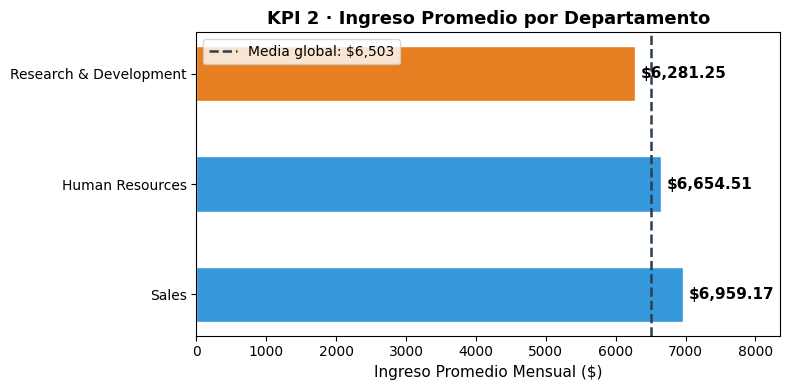

In [ ]:
# ── Cálculo ───────────────────────────────────────────────────────────────────
kpi2 = (df.groupby('Department')['MonthlyIncome']
          .mean()
          .round(2)
          .sort_values(ascending=False)
          .reset_index())
kpi2.columns = ['Departamento', 'Ingreso Promedio Mensual ($)']

ingreso_global = df['MonthlyIncome'].mean()

print("━" * 55)
print(" KPI 2 · INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO")
print("━" * 55)
for _, row in kpi2.iterrows():
    delta = row['Ingreso Promedio Mensual ($)'] - ingreso_global
    signo = "+" if delta >= 0 else ""
    print(f"  {row['Departamento']:<28} $ {row['Ingreso Promedio Mensual ($)']:>8,.2f}  ({signo}{delta:,.2f} vs media global)")
print(f"  {'─'*52}")
print(f"  Ingreso promedio global          $ {ingreso_global:>8,.2f}")
print("━" * 55)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['#3498db' if v >= ingreso_global else '#e67e22' for v in kpi2['Ingreso Promedio Mensual ($)']]
bars = ax.barh(kpi2['Departamento'], kpi2['Ingreso Promedio Mensual ($)'],
               color=colors_bar, edgecolor='white', height=0.5)
ax.axvline(ingreso_global, color='#2c3e50', linewidth=1.8, linestyle='--', label=f'Media global: ${ingreso_global:,.0f}')
for bar, val in zip(bars, kpi2['Ingreso Promedio Mensual ($)']):
    ax.text(val + 80, bar.get_y() + bar.get_height()/2,
            f'${val:,.2f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Ingreso Promedio Mensual ($)', fontsize=11)
ax.set_title('KPI 2 · Ingreso Promedio por Departamento', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, kpi2['Ingreso Promedio Mensual ($)'].max() * 1.2)
plt.tight_layout()
plt.show()

---
## KPI 3 — Índice de Balance Vida-Trabajo Promedio por Cargo

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KPI 3 · BALANCE VIDA-TRABAJO PROMEDIO POR CARGO
 Escala: 1 = Malo  |  2 = Regular  |  3 = Bueno  |  4 = Excelente
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Research Scientist             2.678  RIESGO ALTO
  Healthcare Representative      2.702  RIESGO ALTO
  Laboratory Technician          2.718  RIESGO ALTO
  Manufacturing Director         2.766
  Manager                        2.775
  Sales Executive                2.804
  Research Director              2.862
  Sales Representative           2.892
  Human Resources                2.923
  ───────────────────────────────────────────────────────
  WLB promedio global              2.761
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


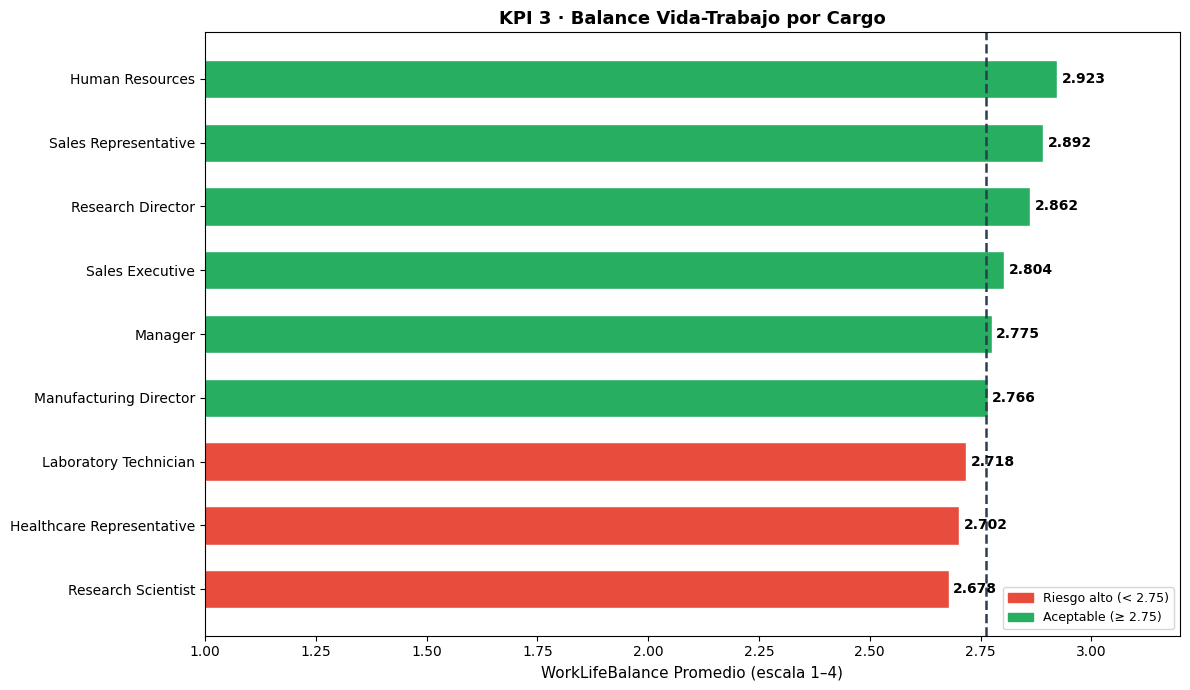

In [ ]:
# ── Cálculo ───────────────────────────────────────────────────────────────────
kpi3 = (df.groupby('JobRole')['WorkLifeBalance']
          .mean()
          .round(3)
          .sort_values()
          .reset_index())
kpi3.columns = ['Cargo (JobRole)', 'WLB Promedio (1-4)']
wlb_global = df['WorkLifeBalance'].mean()

print("━" * 60)
print(" KPI 3 · BALANCE VIDA-TRABAJO PROMEDIO POR CARGO")
print(" Escala: 1 = Malo  |  2 = Regular  |  3 = Bueno  |  4 = Excelente")
print("━" * 60)
for _, row in kpi3.iterrows():
    nivel = row['WLB Promedio (1-4)']
    alerta = "  RIESGO ALTO" if nivel < 2.75 else ""
    print(f"  {row['Cargo (JobRole)']:<30} {nivel:.3f}{alerta}")
print(f"  {'─'*55}")
print(f"  WLB promedio global              {wlb_global:.3f}")
print("━" * 60)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
palette = ['#e74c3c' if v < 2.75 else '#27ae60' for v in kpi3['WLB Promedio (1-4)']]
bars = ax.barh(kpi3['Cargo (JobRole)'], kpi3['WLB Promedio (1-4)'],
               color=palette, edgecolor='white', height=0.6)
ax.axvline(wlb_global, color='#2c3e50', linewidth=1.8, linestyle='--',
           label=f'Media global: {wlb_global:.3f}')
for bar, val in zip(bars, kpi3['WLB Promedio (1-4)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
rojo  = mpatches.Patch(color='#e74c3c', label='Riesgo alto (< 2.75)')
verde = mpatches.Patch(color='#27ae60', label='Aceptable (≥ 2.75)')
ax.legend(handles=[rojo, verde], fontsize=9, loc='lower right')
ax.set_xlabel('WorkLifeBalance Promedio (escala 1–4)', fontsize=11)
ax.set_title('KPI 3 · Balance Vida-Trabajo por Cargo', fontsize=13, fontweight='bold')
ax.set_xlim(1, 3.2)
plt.tight_layout()
plt.show()

---
## KPI 4 — Brecha de Estancamiento Laboral

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KPI 4 · BRECHA DE ESTANCAMIENTO LABORAL
 (Base: solo empleados activos — Attrition = No)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Empleados activos analizados : 1,233
  Con estancamiento (Brecha>0) : 812  (65.9%)
  Sin estancamiento (Brecha≤0) : 421  (34.1%)
  ─────────────────────────────────────
  Brecha promedio global    : 2.25 años

  Brecha promedio por departamento:
    Sales                        2.40 años
    Research & Development       2.21 años
    Human Resources              1.90 años
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


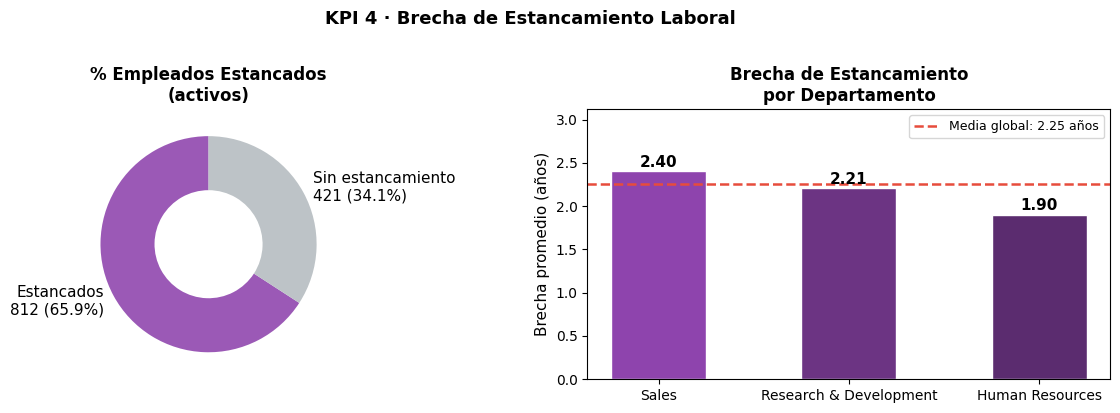

In [ ]:
# ── Cálculo (solo empleados activos) ─────────────────────────────────────────
activos = df[df['Attrition'] == 'No'].copy()
activos['Brecha_Estancamiento'] = activos['YearsInCurrentRole'] - activos['YearsSinceLastPromotion']

brecha_prom   = activos['Brecha_Estancamiento'].mean()
estancados    = (activos['Brecha_Estancamiento'] > 0).sum()
no_estancados = (activos['Brecha_Estancamiento'] <= 0).sum()
pct_estanc    = estancados / len(activos) * 100
brecha_dept   = (activos.groupby('Department')['Brecha_Estancamiento']
                  .mean().round(2).sort_values(ascending=False))

print("━" * 60)
print(" KPI 4 · BRECHA DE ESTANCAMIENTO LABORAL")
print(" (Base: solo empleados activos — Attrition = No)")
print("━" * 60)
print(f"  Empleados activos analizados : {len(activos):,}")
print(f"  Con estancamiento (Brecha>0) : {estancados:,}  ({pct_estanc:.1f}%)")
print(f"  Sin estancamiento (Brecha≤0) : {no_estancados:,}  ({100-pct_estanc:.1f}%)")
print(f"  ─────────────────────────────────────")
print(f"  Brecha promedio global    : {brecha_prom:.2f} años")
print()
print("  Brecha promedio por departamento:")
for dept, val in brecha_dept.items():
    print(f"    {dept:<28} {val:.2f} años")
print("━" * 60)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: dona de estancamiento
ax1 = axes[0]
sizes2  = [estancados, no_estancados]
labels2 = [f'Estancados\n{estancados:,} ({pct_estanc:.1f}%)',
           f'Sin estancamiento\n{no_estancados:,} ({100-pct_estanc:.1f}%)']
colors2 = ['#9b59b6', '#bdc3c7']
ax1.pie(sizes2, labels=labels2, colors=colors2, startangle=90,
        wedgeprops={'width': 0.5}, textprops={'fontsize': 11})
ax1.set_title('% Empleados Estancados\n(activos)', fontsize=12, fontweight='bold')

# Derecha: brecha por departamento
ax2 = axes[1]
bars2 = ax2.bar(brecha_dept.index, brecha_dept.values,
                color=['#8e44ad', '#6c3483', '#5b2c6f'], edgecolor='white', width=0.5)
ax2.axhline(brecha_prom, color='#e74c3c', linewidth=1.8, linestyle='--',
            label=f'Media global: {brecha_prom:.2f} años')
for bar, val in zip(bars2, brecha_dept.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Brecha promedio (años)', fontsize=11)
ax2.set_title('Brecha de Estancamiento\npor Departamento', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, brecha_dept.max() * 1.3)

plt.suptitle('KPI 4 · Brecha de Estancamiento Laboral', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# REPORTE ESCRITO — Análisis de KPIs de Gestión de Talento Humano
---

## KPI 1 · Tasa de Rotación de Personal (Attrition Rate)

| Métrica | Valor |
|---|---|
| Total de empleados | 1 470 |
| Empleados que salieron | 237 |
| **Attrition Rate** | **16.12 %** |
| Periodo | Historial completo del dataset |

**Interpretación de negocio:**  
Una tasa de rotación del **16.12 %** supera el umbral saludable de referencia del 10 % anual para la industria, lo que indica un riesgo crítico de pérdida de personal. Este indicador activa una alerta en el módulo de Gestión de Talento Humano que debe informar a la gerencia para diseñar planes inmediatos de retención y reducir los costos asociados al reclutamiento y capacitación de nuevo personal.

---

## KPI 2 · Ingreso Promedio Mensual por Departamento

| Departamento | Ingreso Promedio Mensual ($) | Δ vs. Media Global |
|---|---|---|
| Sales | 6 959.17 | +456.24 |
| Human Resources | 6 654.51 | +151.58 |
| Research & Development | 6 281.25 | −221.68 |
| **Media global** | **6 502.93** | — |

**Interpretación de negocio:**  
El área de **"Sales"** lidera la compensación con un ingreso superior a la media corporativa, mientras que **"Research & Development"** —el departamento con mayor dotación de personal— presenta el salario promedio más bajo, lo que podría explicar parte de su tasa de renuncia. El módulo de compensaciones del ERP debe revisar las bandas salariales de R&D para corregir la brecha y mantener la competitividad en la captación de talento técnico especializado.

---

## KPI 3 · Índice de Balance Vida-Trabajo Promedio por Cargo

| Cargo | WLB Promedio (1–4) | Estado |
|---|---|---|
| Research Scientist | 2.678 | Riesgo alto |
| Healthcare Representative | 2.702 | Riesgo alto |
| Laboratory Technician | 2.718 | Riesgo alto |
| Manufacturing Director | 2.766 | Aceptable |
| Manager | 2.775 | Aceptable |
| Sales Executive | 2.804 | Aceptable |
| Research Director | 2.862 | Aceptable |
| Sales Representative | 2.892 | Aceptable |
| Human Resources | 2.923 | Aceptable |
| **Media global** | **2.761** | — |

**Interpretación de negocio:**  
Los cargos operativos científicos y de laboratorio (**Research Scientist**, **Healthcare Representative**, **Laboratory Technician**) registran los índices de balance vida-trabajo más bajos, todos por debajo de 2.75 sobre 4, configurando una zona de riesgo de desgaste y futuras renuncias. El sistema HRIS debe generar alertas automáticas para que Recursos Humanos implemente programas de flexibilidad horaria y bienestar específicamente en estos roles antes de que el agotamiento se traduzca en más renuncias.

---

## KPI 4 · Brecha de Estancamiento Laboral

| Métrica | Valor |
|---|---|
| Empleados activos analizados | 1 233 |
| Empleados con estancamiento (Brecha > 0) | 812 (65.9 %) |
| Empleados sin estancamiento (Brecha ≤ 0) | 421 (34.1 %) |
| **Brecha promedio global** | **2.25 años** |
| Research & Development | mayor brecha departamental |

**Interpretación de negocio:**  
El **65.9 %** de los empleados activos lleva más tiempo en su puesto actual del que ha transcurrido desde su última promoción, con una brecha media de **2.25 años**, lo que evidencia un estancamiento sistémico en las líneas de carrera internas. Este estancamiento reduce la motivación y la productividad; el ERP debe activar un flujo de trabajo automático en el módulo de Gestión del Desempeño para que los gerentes de área revisen y actualicen los planes de desarrollo individual de los colaboradores con mayor antigüedad sin ascenso.
